# Notebook 10 — Summary: All SWH Models × All Locations

Run after nb01–nb09 complete. Produces ranking tables, heatmaps, Excel export.

In [1]:
# Cell 1 — Environment + Load
RUN_ENV  = 'local'
BASE_DIR = r'c:\Users\DA IICT K\Desktop\BMP_files\SWH_codes'
if RUN_ENV == 'colab':
    from google.colab import drive; drive.mount('/content/drive')
    BASE_DIR = '/content/drive/MyDrive/BMP_Data/'

import os, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore') if 'warnings' in dir() else None

SAVE_DIR = os.path.join(BASE_DIR, 'results_SWH/')
TARGET   = 95.0

csvs = sorted(glob.glob(os.path.join(SAVE_DIR, 'results_*_SWH.csv')))
print(f'Found {len(csvs)} result CSVs:')
for c in csvs: print(f'  {os.path.basename(c)}')
if not csvs: raise FileNotFoundError(f'No CSVs in {SAVE_DIR}. Run nb01-nb09 first.')

df_all = pd.concat([pd.read_csv(c) for c in csvs], ignore_index=True)

def cwc(p, m, target=TARGET, eta=50):
    pf=p/100.0; tf=target/100.0
    return m if pf>=tf else m*np.exp(-eta*(pf-tf))

if 'avg_cwc' not in df_all.columns:
    df_all['avg_cwc'] = df_all.apply(lambda r: cwc(r['avg_picp'], r['avg_mpiw']), axis=1)

print(f'\nTotal rows: {len(df_all)}')
print('Models:', sorted(df_all['model'].unique()))

Found 9 result CSVs:
  results_ARIMA_SWH.csv
  results_DeepAR_SWH.csv
  results_GRU_SWH.csv
  results_LSTM_KDE_SWH.csv
  results_LSTM_SWH.csv
  results_MDN_SWH.csv
  results_Mamba_SWH.csv
  results_SimpleRNN_SWH.csv
  results_Transformer_SWH.csv

Total rows: 70
Models: ['ARIMA(2, 1, 1)-Bootstrap', 'DeepAR-NLL-Gaussian', 'GRU-Quantile', 'GRU-Tube', 'LSTM-KDE', 'LSTM-Quantile', 'LSTM-Tube', 'MDN-GRU-K3', 'Mamba-Quantile', 'Mamba-Tube', 'SimpleRNN-Quantile', 'SimpleRNN-Tube', 'Transformer-Quantile', 'Transformer-Tube']


In [2]:
# Cell 2 — Per-location ranking tables
LOCS = ['Arabian_Sea','Bay_of_Bengal','Andaman_Sea','Lakshadweep','South_IO']
all_tables = {}
import warnings; warnings.filterwarnings('ignore')

print('='*105)
print('PER-LOCATION RESULTS — SWH (ranked by WIS, PICP >= 95% eligible for bold)')
print('='*105)

for loc in LOCS:
    sub = df_all[df_all['location']==loc].copy()
    if len(sub)==0: continue
    sub = sub.sort_values('avg_cwc').reset_index(drop=True)
    sub['rank'] = range(1, len(sub)+1)
    all_tables[loc] = sub
    lat = sub['lat'].iloc[0]; lon = sub['lon'].iloc[0]
    print(f'\n{"─"*105}')
    print(f'  {loc}  ({lat}N, {lon}E)')
    print(f'{"─"*105}')
    print(f'  {"Rank":>4}  {"Model":<28}  {"PICP%":>7}  {"+/-":>5}  {"MPIW(m)":>9}  {"WIS":>9}  {"CWC":>9}  {"Status":>12}')
    print(f'  {"─"*4}  {"─"*28}  {"─"*7}  {"─"*5}  {"─"*9}  {"─"*9}  {"─"*9}  {"─"*12}')
    for _, r in sub.iterrows():
        if r['avg_picp']>=94 and r['avg_picp']<=96: stat="✓ On target"
        elif r['avg_picp']>96:                       stat="↑ Overcov."
        elif r['avg_picp']>=90:                      stat="~ Near"
        else:                                        stat="✗ Low cov."
        w_s=f"{r['avg_wis']:.5f}" if pd.notna(r.get('avg_wis')) else "      --"
        c_s=f"{r['avg_cwc']:.5f}" if pd.notna(r.get('avg_cwc')) else "      --"
        sp=f"{r['std_picp']:.1f}" if pd.notna(r.get('std_picp')) else "  --"
        print(f'  {r["rank"]:>4}  {r["model"]:<28}  {r["avg_picp"]:7.1f}  {sp:>5}  '
              f'{r["avg_mpiw"]:9.4f}  {w_s:>9}  {c_s:>9}  {stat:>12}')

for loc, sub in all_tables.items():
    sub.to_csv(os.path.join(SAVE_DIR, f'table_SWH_{loc}.csv'), index=False)
print(f'\nPer-location CSVs saved.')

PER-LOCATION RESULTS — SWH (ranked by WIS, PICP >= 95% eligible for bold)

─────────────────────────────────────────────────────────────────────────────────────────────────────────
  Arabian_Sea  (15.0N, 65.0E)
─────────────────────────────────────────────────────────────────────────────────────────────────────────
  Rank  Model                           PICP%    +/-    MPIW(m)        WIS        CWC        Status
  ────  ────────────────────────────  ───────  ─────  ─────────  ─────────  ─────────  ────────────
     1  MDN-GRU-K3                       96.9    0.6     0.8386    0.88834    0.83856    ↑ Overcov.
     2  SimpleRNN-Tube                   97.9    0.4     1.0071    1.06984    1.00706    ↑ Overcov.
     3  ARIMA(2, 1, 1)-Bootstrap         94.1    0.0     0.8397    1.04014    1.34092   ✓ On target
     4  GRU-Tube                         97.5    0.2     1.4403    1.56233    1.44034    ↑ Overcov.
     5  LSTM-KDE                         98.1    0.4     2.6166    2.74622    2.616

In [3]:
# Cell 3 — Overall ranking
ranking = df_all.groupby('model').agg(
    Avg_PICP=('avg_picp','mean'), Min_PICP=('avg_picp','min'),
    Avg_MPIW=('avg_mpiw','mean'), Avg_WIS =('avg_wis', 'mean'),
    Med_CWC =('avg_cwc', 'median'),
    Locations=('location','count'), Seeds=('n_seeds','first'),
).reset_index().sort_values('Avg_WIS')
ranking['Rank'] = range(1, len(ranking)+1)
ranking['Pass5'] = ranking.apply(
    lambda r: f"{df_all[df_all['model']==r['model']]['avg_picp'].apply(lambda p: p>=95).sum()}/{r['Locations']}",
    axis=1)

def cat(p): return "Excellent" if 94<=p<=96 else ("Good" if 92<=p<94 else ("Overcov." if p>96 else "Poor"))
ranking['Coverage'] = ranking['Avg_PICP'].apply(cat)

print('\n'+'='*105)
print('GLOBAL RANKING — SWH (by mean WIS)')
print('='*105)
print(f'  {"Rank":>4}  {"Model":<28}  {"AvgPICP%":>9}  {"MinPICP%":>9}  {"AvgMPIW":>9}  {"AvgWIS":>9}  {"MedCWC":>9}  {"Pass5":>6}  {"Coverage"}')
print('-'*105)
for _,r in ranking.iterrows():
    star = " ←BEST" if r['Rank']==1 else ""
    print(f'  {r["Rank"]:>4}  {r["model"]:<28}  {r["Avg_PICP"]:9.1f}  {r["Min_PICP"]:9.1f}  '
          f'{r["Avg_MPIW"]:9.4f}  {r["Avg_WIS"]:9.4f}  {r["Med_CWC"]:9.4f}  {r["Pass5"]:>6}  '
          f'{r["Coverage"]}{star}')

ranking.to_csv(os.path.join(SAVE_DIR, 'table_SWH_ranking.csv'), index=False)
print(f'\nSaved: table_SWH_ranking.csv')


GLOBAL RANKING — SWH (by mean WIS)
  Rank  Model                          AvgPICP%   MinPICP%    AvgMPIW     AvgWIS     MedCWC   Pass5  Coverage
---------------------------------------------------------------------------------------------------------
     1  GRU-Quantile                       81.1       76.7     0.4918     0.6676   451.7798     0/5  Poor ←BEST
     2  DeepAR-NLL-Gaussian                85.5       78.5     0.5340     0.6783    33.6807     0/5  Poor
     3  LSTM-Quantile                      81.6       75.5     0.4937     0.6784   215.8464     0/5  Poor
     4  SimpleRNN-Quantile                 79.7       76.7     0.4917     0.6844  1304.2061     0/5  Poor
     5  MDN-GRU-K3                         96.6       94.9     0.8088     0.8423     0.8455     4/5  Overcov.
     6  ARIMA(2, 1, 1)-Bootstrap           95.0       93.2     0.8634     0.9539     1.3409     1/5  Excellent
     7  SimpleRNN-Tube                     96.9       96.0     0.9333     0.9668     1.0071     5

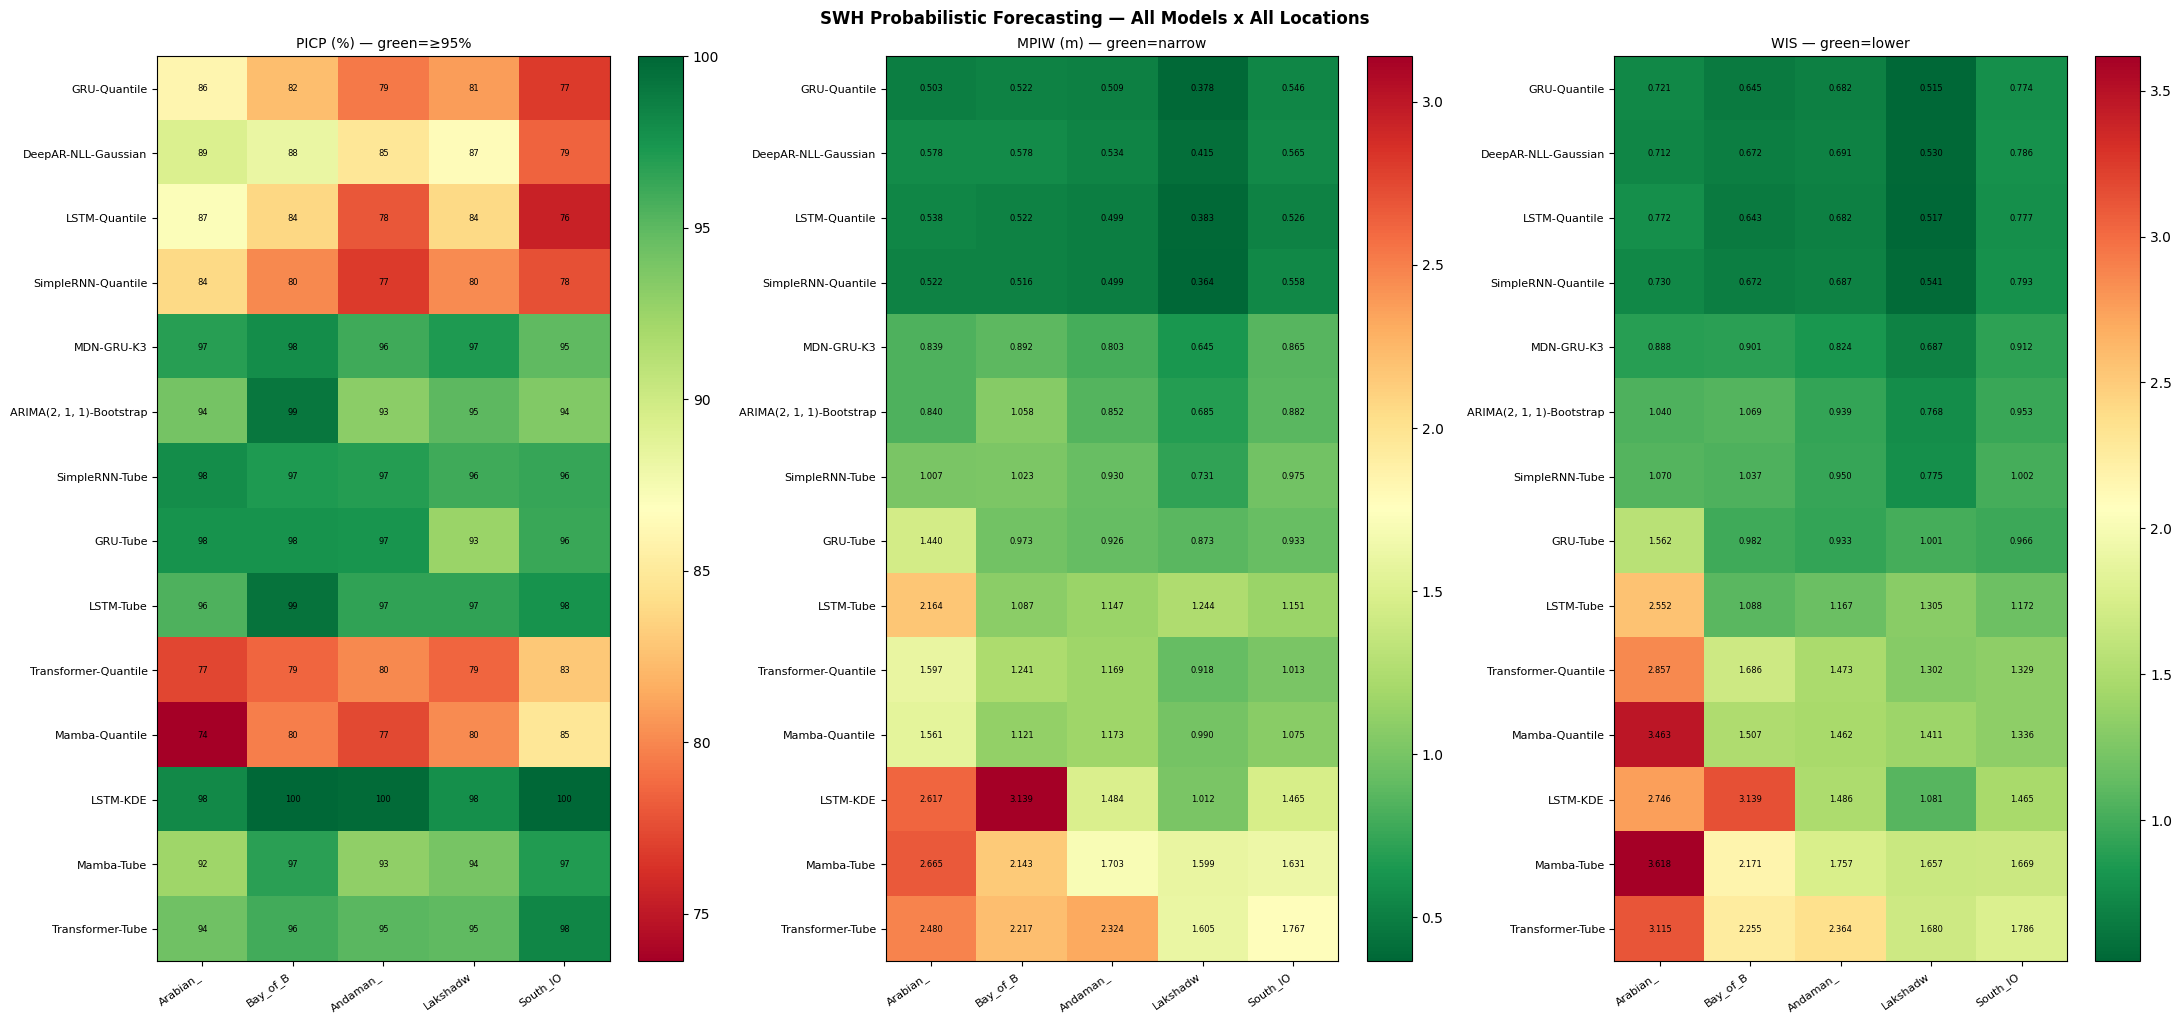

Saved: c:\Users\DA IICT K\Desktop\BMP_files\SWH_codes\results_SWH/heatmap_SWH.png


In [4]:
# Cell 4 — Heatmaps
LOCS = ['Arabian_Sea','Bay_of_Bengal','Andaman_Sea','Lakshadweep','South_IO']
mods = ranking['model'].tolist()
def mat(metric):
    m = np.full((len(mods),len(LOCS)),np.nan)
    for i,mod in enumerate(mods):
        for j,loc in enumerate(LOCS):
            r=df_all[(df_all['model']==mod)&(df_all['location']==loc)]
            if len(r): m[i,j]=float(r[metric].values[0])
    return m

fig, axes = plt.subplots(1,3,figsize=(22,max(4,len(mods)*0.6+2)))
for ax,(metric,title,cmap) in zip(axes,[
    ('avg_picp','PICP (%) — green=≥95%','RdYlGn'),
    ('avg_mpiw','MPIW (m) — green=narrow','RdYlGn_r'),
    ('avg_wis', 'WIS — green=lower','RdYlGn_r')]):
    m=mat(metric)
    im=ax.imshow(m,cmap=cmap,aspect='auto')
    ax.set_xticks(range(len(LOCS))); ax.set_xticklabels([l[:8] for l in LOCS],rotation=35,ha='right',fontsize=8)
    ax.set_yticks(range(len(mods))); ax.set_yticklabels(mods,fontsize=8)
    ax.set_title(title,fontsize=10); plt.colorbar(im,ax=ax)
    for i in range(len(mods)):
        for j in range(len(LOCS)):
            if not np.isnan(m[i,j]):
                ax.text(j,i,f'{m[i,j]:.3f}' if metric!='avg_picp' else f'{m[i,j]:.0f}',
                        ha='center',va='center',fontsize=6)
fig.suptitle('SWH Probabilistic Forecasting — All Models x All Locations',fontsize=12,fontweight='bold')
plt.tight_layout()
fp=os.path.join(SAVE_DIR,'heatmap_SWH.png')
plt.savefig(fp,dpi=140,bbox_inches='tight'); plt.show(); print(f'Saved: {fp}')

In [5]:
# Cell 5 — Export Excel
with pd.ExcelWriter(os.path.join(SAVE_DIR,'Final_Results_SWH.xlsx'),engine='openpyxl') as wr:
    ranking.to_excel(wr,sheet_name='Overall_Ranking',index=False)
    for loc,sub in all_tables.items():
        sub.to_excel(wr,sheet_name=loc[:28],index=False)
    df_all.to_excel(wr,sheet_name='All_Results',index=False)
    meta=pd.DataFrame({'Metric':['PICP','MPIW','WIS','CWC'],
        'Full Name':['Prediction Interval Coverage Probability','Mean Prediction Interval Width',
                     'Winkler Interval Score','Coverage Width-based Criterion'],
        'Formula':['mean(y in [lo,hi])*100%','mean(hi-lo) in metres',
                   'mean(width+10*miss_penalty)','MPIW*exp(-50*(PICP/100-0.95)) if PICP<95%'],
        'Better When':['Near 95%','Lower','Lower','Lower'],
        'Note':['Same as SLA','SWH MPIW ~10-50x larger than SLA','alpha=0.20 (p10/p90)','eta=50 standard']})
    meta.to_excel(wr,sheet_name='Metric_Definitions',index=False)
print('Final_Results_SWH.xlsx saved.')
print()
print('='*60)
print('SWH vs SLA COMPARISON (expected differences):')
print('  SLA MPIW: ~0.01-0.03 m  |  SWH MPIW: ~0.15-0.50 m')
print('  Both use same PICP target: 95%')
print('  Best model family expected to be the same: GRU/SimpleRNN')
print('='*60)

Final_Results_SWH.xlsx saved.

SWH vs SLA COMPARISON (expected differences):
  SLA MPIW: ~0.01-0.03 m  |  SWH MPIW: ~0.15-0.50 m
  Both use same PICP target: 95%
  Best model family expected to be the same: GRU/SimpleRNN
